# Convolutional Neural Network for Indian Sign Language

## Part 1: Data Loading

In [3]:
# from google.colab import files
# !pip install kaggle

In [4]:
import os
os.environ['KAGGLE_API_TOKEN']='KGAT_6e25a135cbc02cae857e4e183f4c42de'

In [5]:
!kaggle datasets download -d rushilverma07/indian-sign-language-alphabet-dataset
!unzip indian-sign-language-alphabet-dataset -d isl_new_double

DIR="/content/isl_new_double/dataset - Gesture Speech"

Streaming output truncated to the last 5000 lines.
  inflating: isl_new_double/dataset - Gesture Speech/w/my567.jpg  
  inflating: isl_new_double/dataset - Gesture Speech/w/my568.jpg  
  inflating: isl_new_double/dataset - Gesture Speech/w/my569.jpg  
  inflating: isl_new_double/dataset - Gesture Speech/w/my57.jpg  
  inflating: isl_new_double/dataset - Gesture Speech/w/my570.jpg  
  inflating: isl_new_double/dataset - Gesture Speech/w/my571.jpg  
  inflating: isl_new_double/dataset - Gesture Speech/w/my572.jpg  
  inflating: isl_new_double/dataset - Gesture Speech/w/my573.jpg  
  inflating: isl_new_double/dataset - Gesture Speech/w/my574.jpg  
  inflating: isl_new_double/dataset - Gesture Speech/w/my575.jpg  
  inflating: isl_new_double/dataset - Gesture Speech/w/my576.jpg  
  inflating: isl_new_double/dataset - Gesture Speech/w/my577.jpg  
  inflating: isl_new_double/dataset - Gesture Speech/w/my578.jpg  
  inflating: isl_new_double/dataset - Gesture Speech/w/my579.jpg  
  inflating:

In [6]:
from PIL import Image

sizes=set()
count=0

for root,dirs,files in os.walk(DIR): # walks from root to directories.
# so goes from Hindi... -> a, aa, i .... (recursively) and via files in each
  for file in files:
    if file.lower().endswith(".jpg"): # ensures jpg file
      img=Image.open(os.path.join(root,file))
      count+=1
      sizes.add(img.size) # to get all the unique sizes for an image in the dataset


sizes,count

({(100, 100),
  (250, 250),
  (252, 252),
  (266, 266),
  (292, 292),
  (294, 294),
  (302, 302),
  (312, 312),
  (342, 342),
  (350, 350),
  (352, 352),
  (358, 358),
  (384, 384),
  (450, 450),
  (496, 496),
  (544, 544),
  (576, 576),
  (614, 614),
  (658, 658)},
 32400)

In [7]:
from torchvision import datasets,transforms

dataset=datasets.ImageFolder(DIR)
len_data=len(dataset)
len(dataset)
# transform=transforms.Grayscale(num_output_channels=3)

32400

In [8]:
#  splitting into test and train data
from torch.utils.data import random_split

train_len=int(len_data*0.8) # 80 percent in training dataset
test_len=len_data-train_len

train_len,test_len

(25920, 6480)

In [9]:
# train_dataset,test_datasets=random_split(dataset,[train_len,test_len]) # incorrect cuz same imagefolder so transform applied to both is same
# len(train_dataset),len(test_datasets)

transform_train=transforms.Compose(
    [
    transforms.Resize((128,128)),
    transforms.ToTensor(), # pixels lie between 0 and 1
    transforms.RandomRotation(20),
    transforms.RandomAffine(degrees=10,translate=(0.1,0.1),scale=(0.9,1.1)),
    transforms.ColorJitter(brightness=0.3,saturation=0.3,contrast=0.3),
    transforms.Normalize(mean=[0.5,0.5,0.5],std=[0.5,0.5,0.5]), # pixels lie btw -1 -> 1. [0.5,0.5,0.5] for [R,G,B]
    transforms.RandomErasing(p=0.3,scale=(0.02,0.1))
    ]
    )

transform_test=transforms.Compose(
   [
    transforms.Resize((128,128)),
    transforms.ToTensor(), # pixels lie between 0 and 1
    transforms.Normalize(mean=[0.5,0.5,0.5],std=[0.5,0.5,0.5]) # pixels lie btw -1 -> 1. [0.5,0.5,0.5] for [R,G,B]
    ]
    )

In [10]:
from torch.utils.data import Subset
import torch

train_dataset=datasets.ImageFolder(DIR,transform=transform_train)
test_dataset=datasets.ImageFolder(DIR,transform=transform_test)

# now test and train both have all 48000 images but with diff types of transforms.
# so we select x images for traina nd rest for train

torch.manual_seed(42) # DO NOT FORGET THIS!

idx=torch.randperm(len_data) # list of indices in random order, split it by 80% of dataset length

train_id=idx[:train_len]
test_id=idx[train_len:]

train_data_sub=Subset(train_dataset,train_id) # subset makes a copy of the image in that specific variable
test_data_sub=Subset(test_dataset,test_id)

len(train_data_sub),len(test_data_sub)

(25920, 6480)

In [11]:
print(len(train_data_sub))
print(len(test_data_sub))

print(train_id[:10])
print(test_id[:10])

print(set(train_id.tolist()) & set(test_id.tolist()))

25920
6480
tensor([ 9942, 18461,  4948, 16171, 20210, 11400,  9664, 31876,  1654, 10766])
tensor([ 1217,   783, 21787, 26527, 22163, 31037,  2372, 25185,  5856, 28207])
set()


In [12]:
# train_dataset.classes
import os
print(os.listdir(DIR))
print(dataset.classes)
len(dataset.classes)

['k', 'w', 's', 'e', 'h', 'f', 'z', 'n', 't', 'm', 'v', '{', 'c', 'b', 'p', 'q', 'l', 'y', 'g', 'r', 'x', 'j', 'd', 'u', 'o', 'i', 'a']
['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', '{']


27

In [13]:
print(dataset.class_to_idx)

{'a': 0, 'b': 1, 'c': 2, 'd': 3, 'e': 4, 'f': 5, 'g': 6, 'h': 7, 'i': 8, 'j': 9, 'k': 10, 'l': 11, 'm': 12, 'n': 13, 'o': 14, 'p': 15, 'q': 16, 'r': 17, 's': 18, 't': 19, 'u': 20, 'v': 21, 'w': 22, 'x': 23, 'y': 24, 'z': 25, '{': 26}


In [14]:
from collections import Counter

counts=Counter(label for img,label in dataset) # to check for an even dstibution for the dataset
print(counts)

Counter({0: 1200, 1: 1200, 2: 1200, 3: 1200, 4: 1200, 5: 1200, 6: 1200, 7: 1200, 8: 1200, 9: 1200, 10: 1200, 11: 1200, 12: 1200, 13: 1200, 14: 1200, 15: 1200, 16: 1200, 17: 1200, 18: 1200, 19: 1200, 20: 1200, 21: 1200, 22: 1200, 23: 1200, 24: 1200, 25: 1200, 26: 1200})


In [15]:
img,label=train_data_sub[0]
img.min(),img.max(),img.mean(),label # cuz doing jst img was showing most the pixels as -1 cuz of the black bg.
# This way, its ensured that the tensors arent jst a bunch of -1s

(tensor(-1.), tensor(0.5297), tensor(-0.7759), 8)

In [16]:
print(f"Image shape: {img.shape}")

Image shape: torch.Size([3, 128, 128])


8: i


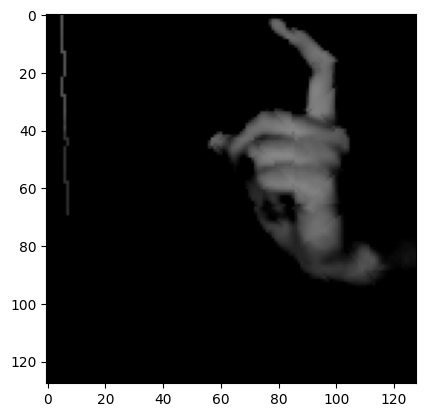

In [17]:
import matplotlib.pyplot as plt
plt.imshow(img.permute(1,2,0)) # black and white image cuz the 0-> 1 is converted to -1 -> 1 for better training over a consistent scale
# 1,2,0 cuz imshow expects (height,width,channels) instead of the (channels,height,width) in img.shape()
print(f"{label}: {train_data_sub.dataset.classes[label]}")

8: i


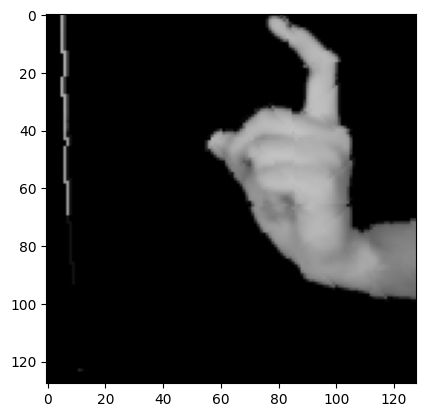

In [18]:
image=img*0.5+0.5 # to undo the normalization

plt.imshow(image.permute(1,2,0)) # black and white image cuz the 0-> 1 is converted to -1 -> 1 for better training over a consistent scale
# 1,2,0 cuz imshow expects (height,width,channels) instead of the (channels,height,width) in img.shape()
print(f"{label}: {train_data_sub.dataset.classes[label]}")

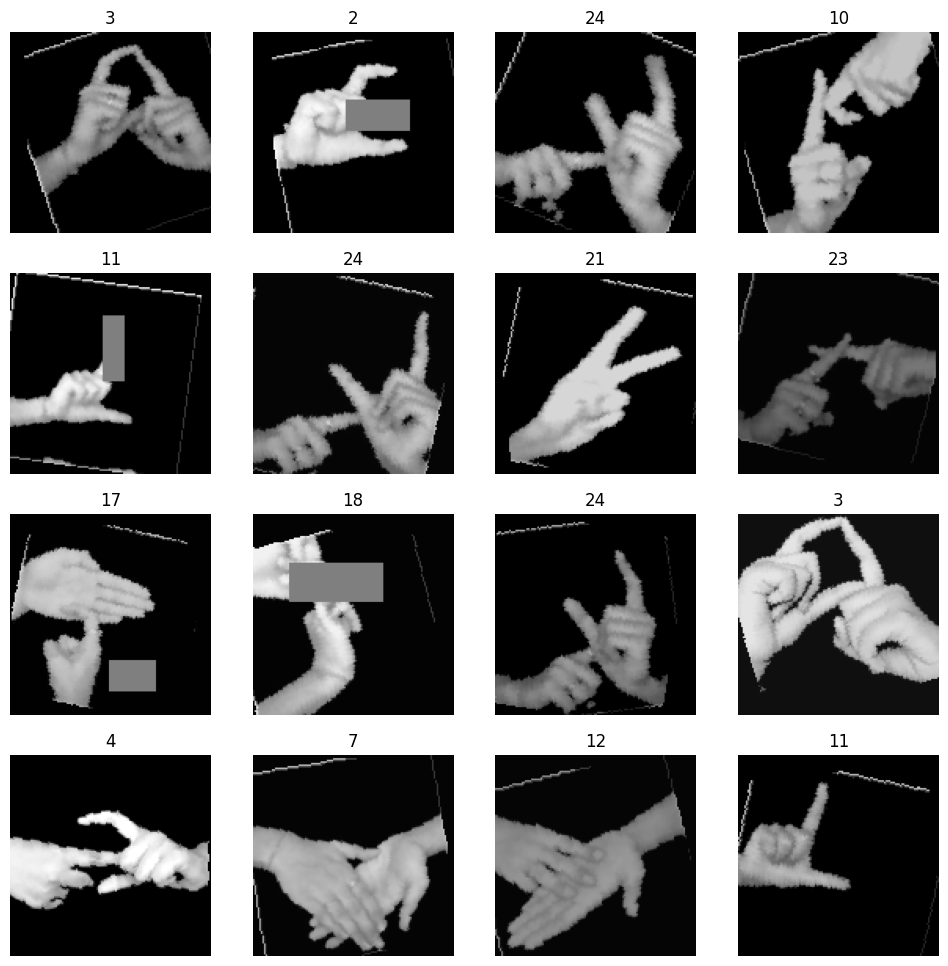

In [19]:
torch.manual_seed(42)
fig=plt.figure(figsize=(12,12))
rows,cols=4,4

for i in range(1,1+(rows*cols)):
  idx_rand=torch.randint(0,len(train_data_sub),size=[1]) # returns one tensor (tensor[15]) (The size part expects a tensor as argument)
  idx_rand=idx_rand.item() # returns the actual index eg 15
  img,label=train_data_sub[idx_rand]
  img=img*0.5+0.5
  fig.add_subplot(rows,cols,i)
  plt.imshow(img.permute(1,2,0))
  # plt.title(train_data_sub.dataset.classes[label]) Not this cuz matplotib dsnt contain devanagiri script
  plt.title(label)
  plt.axis(False)

In [20]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [21]:
from torch.utils.data import DataLoader

Batch_size=64

train_dataloader=DataLoader(train_data_sub,Batch_size,shuffle=True)
test_dataloader=DataLoader(test_data_sub,Batch_size)

len(train_dataloader),len(test_dataloader)

(405, 102)

In [22]:
batch_img_train,batch_labels_train=next(iter(train_dataloader))

batch_labels_train.shape,batch_img_train.shape,batch_labels_train[:5]
# batch labels-> [number of batches] batch img-> [number of batches,colours,height,width]

(torch.Size([64]), torch.Size([64, 3, 128, 128]), tensor([ 4, 14, 20, 17,  0]))

## Part 2: Model Definition

In [23]:
import torch.nn as nn

class ISL_CNN(nn.Module):
  def __init__(self,num_labels):
    super().__init__()
    self.convolution=nn.Sequential(

        # Block 1:
        nn.Conv2d(3,32,3,padding=1), # (3,128,128) -> (32,128,128)
        nn.BatchNorm2d(32),
        nn.ReLU(),
        nn.MaxPool2d(2,2), # this divides img dim by 2 so (32,64,64)

         # Block 2:
        nn.Conv2d(32,64,3,padding=1),  # (32,64,64) -> (64,64,64)
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(2,2), # (64,32,32)

         # Block 3:
        nn.Conv2d(64,128,3,padding=1), # (64,32,32) -> (128,32,32) # DO NOT WRITE THAT 1 WITHOUT THE PADDING
        nn.BatchNorm2d(128),
        nn.ReLU(),
        nn.MaxPool2d(2,2) # (128,16,16)
    )

    self.fully_connected=nn.Sequential(
        nn.Flatten(), # (128,16,16) -> (32768)
        nn.Linear(128*16*16,512), # (512)
        nn.ReLU(),
        nn.Dropout(0.25), # prevents overfitting
        nn.Linear(512,128), # (128)
        nn.ReLU(),
        nn.Linear(128,num_labels) # (nm_labels) which is 40 in this case
    )

  def forward(self,x):
    x=self.convolution(x)
    x=self.fully_connected(x)
    return x

In [24]:
# cnn block has :
# conv
# norm
# relu
# maxpool

# fc block has
# flatten
# linear
# relu
# dropout
# linear

In [25]:
model_0=ISL_CNN(len(dataset.classes)).to(device)
model_0

ISL_CNN(
  (convolution): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fully_connected): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=512, bias=True)
    (2): ReLU()
    (3):

## Part 3: Training Loop

In [31]:
cost_func=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(params=model_0.parameters(),lr=0.001,weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)

In [32]:
def accuracy(y_actual,y_pred):
  correct=torch.eq(y_actual,y_pred).sum()
  acc=(correct.item()/len(y_pred))*100
  return acc

In [35]:
torch.manual_seed(42)

epochs=4

for epoch in range(epochs):
  train_loss=0

  # now, go through all batches per epoch
  for batch,(x,y) in enumerate(train_dataloader):
    # batchnum,tensor of all 64 images, tensor of all 64 labels
    model_0.train()

    x=x.to(device)
    y=y.to(device)

    y_pred=model_0(x)

    loss=cost_func(y_pred,y)

    train_loss+=loss.item() # .item() dont add tensors again!!!

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    if (batch%400)==0:
      print(f"{(batch*len(x))/len(train_dataloader.dataset)} Completed")

  train_loss/=len(train_dataloader)

  test_loss=0
  test_acc=0

  with torch.inference_mode():
    model_0.eval()

    for X,Y in test_dataloader:

      X=X.to(device)
      Y=Y.to(device)

      test_pred=model_0(X)
      test_loss+=cost_func(test_pred,Y).item()
      test_acc+=accuracy(Y,test_pred.argmax(dim=1))
      # test pred will be [64,40], so u need the max i the 40 waala dim to getthe predicted label

    test_loss/=len(test_dataloader)
    test_acc/=len(test_dataloader)

  scheduler.step(test_loss)


  print(f"Epoch: {epoch} | Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")


0.0 Completed
0.9876543209876543 Completed
Epoch: 0 | Train Loss: 0.1393 | Test Loss: 0.0282 | Test Acc: 99.4638
0.0 Completed
0.9876543209876543 Completed
Epoch: 1 | Train Loss: 0.1409 | Test Loss: 0.0150 | Test Acc: 99.5404
0.0 Completed
0.9876543209876543 Completed
Epoch: 2 | Train Loss: 0.1381 | Test Loss: 0.0140 | Test Acc: 99.4638
0.0 Completed
0.9876543209876543 Completed
Epoch: 3 | Train Loss: 0.1280 | Test Loss: 0.0113 | Test Acc: 99.6783


## Part 4: Testing the Model

In [36]:
model_0.eval()
with torch.inference_mode():
    X,Y = next(iter(test_dataloader))
    X,Y = X.to(device),Y.to(device)
    pred=model_0(X).argmax(dim=1)

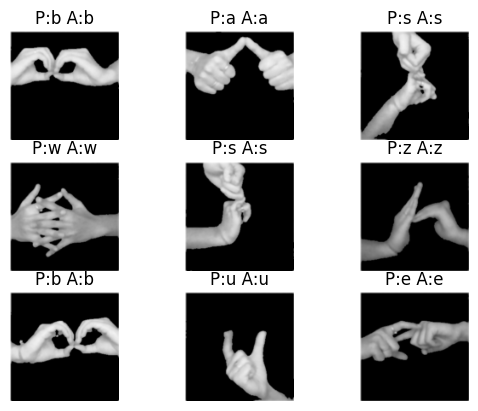

In [37]:
class_names = test_data_sub.dataset.classes  # gets the actual label names

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X[i].cpu().permute(1,2,0)*0.5+0.5)  # undo normalization
    plt.title(f"P:{class_names[pred[i]]} A:{class_names[Y[i]]}")
    plt.axis("off")
plt.show()

In [38]:
# for x,y in enumerate(train_dataloader):
#   print(x,y)

In [39]:
torch.save(model_0.state_dict(),"isl_model_2.pth")
from google.colab import files
files.download("isl_model_2.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [40]:
import json
with open("class_names.json", "w", encoding="utf-8") as f:
    json.dump(dataset.classes, f, ensure_ascii=False)
files.download("class_names.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [41]:
model_1=ISL_CNN(len(dataset.classes)).to(device)
model_1.load_state_dict(torch.load("isl_model_2.pth"))
model_1.eval()

ISL_CNN(
  (convolution): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fully_connected): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=512, bias=True)
    (2): ReLU()
    (3):

## Part 5: Confusion Matrix

In [42]:
!pip install torchmetrics
!pip install mlxtend

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 31.3 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/mlxtend/plotting/plot_confusion_matrix.py:102: RuntimeWarning: invalid value encountered in divide
  normed_conf_mat = conf_mat.astype("float") / total_samples


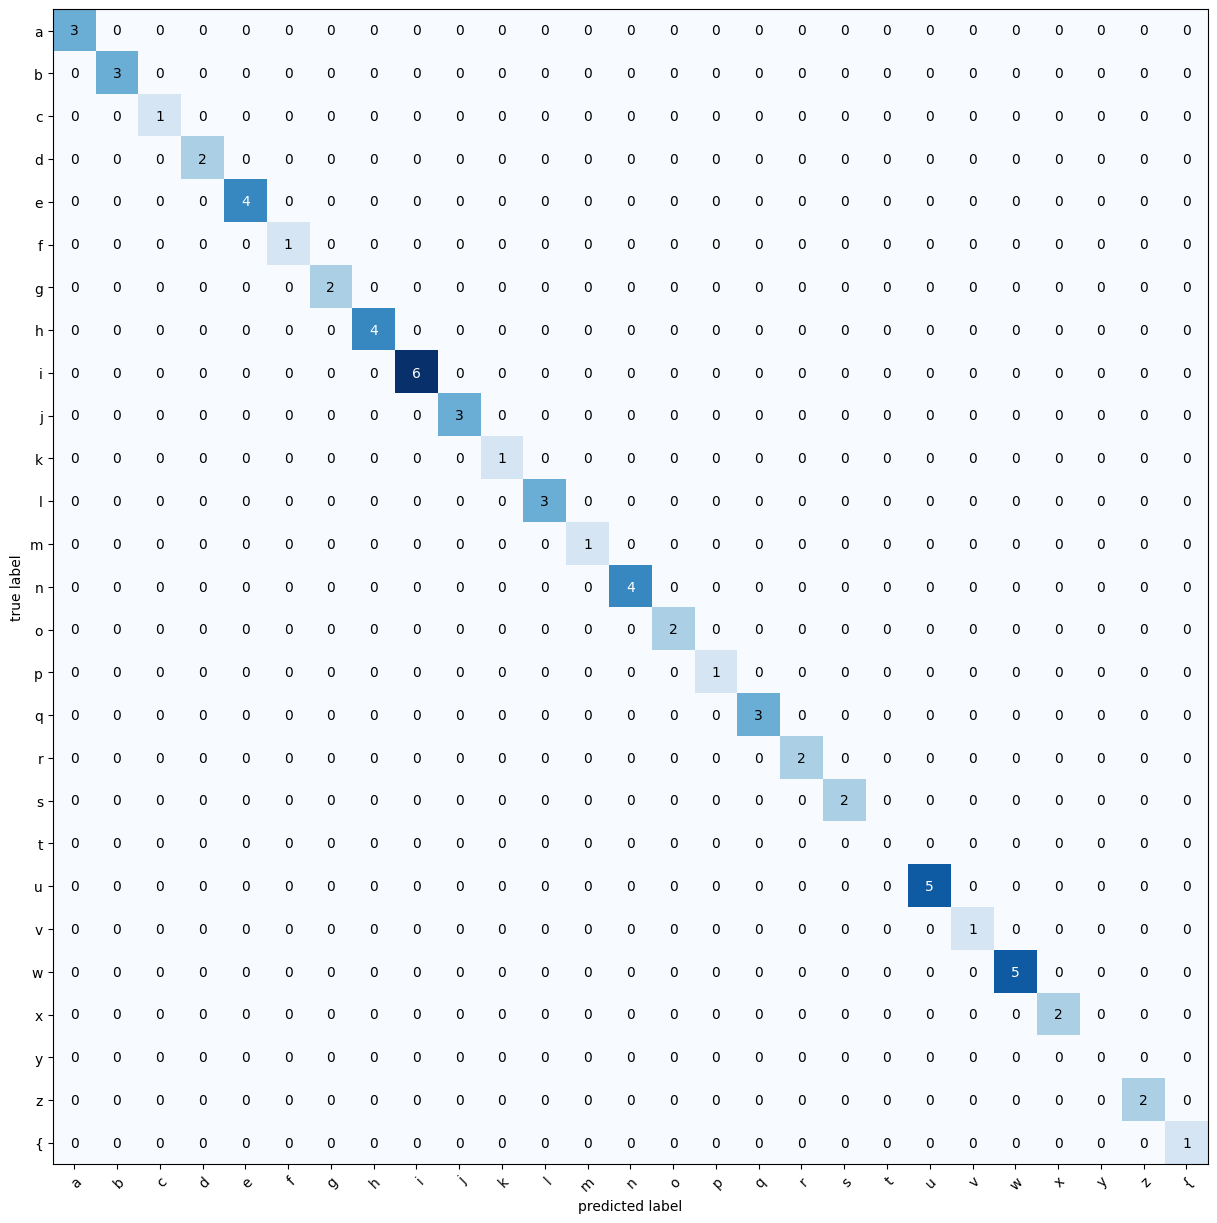

In [43]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

mat=ConfusionMatrix(num_classes=len(class_names),task="multiclass")
mat_tensor=mat(preds=pred.cpu(),target=Y.cpu())

fig,ax=plot_confusion_matrix(conf_mat=mat_tensor.numpy(),figsize=(15,15),class_names=class_names)
plt.show()

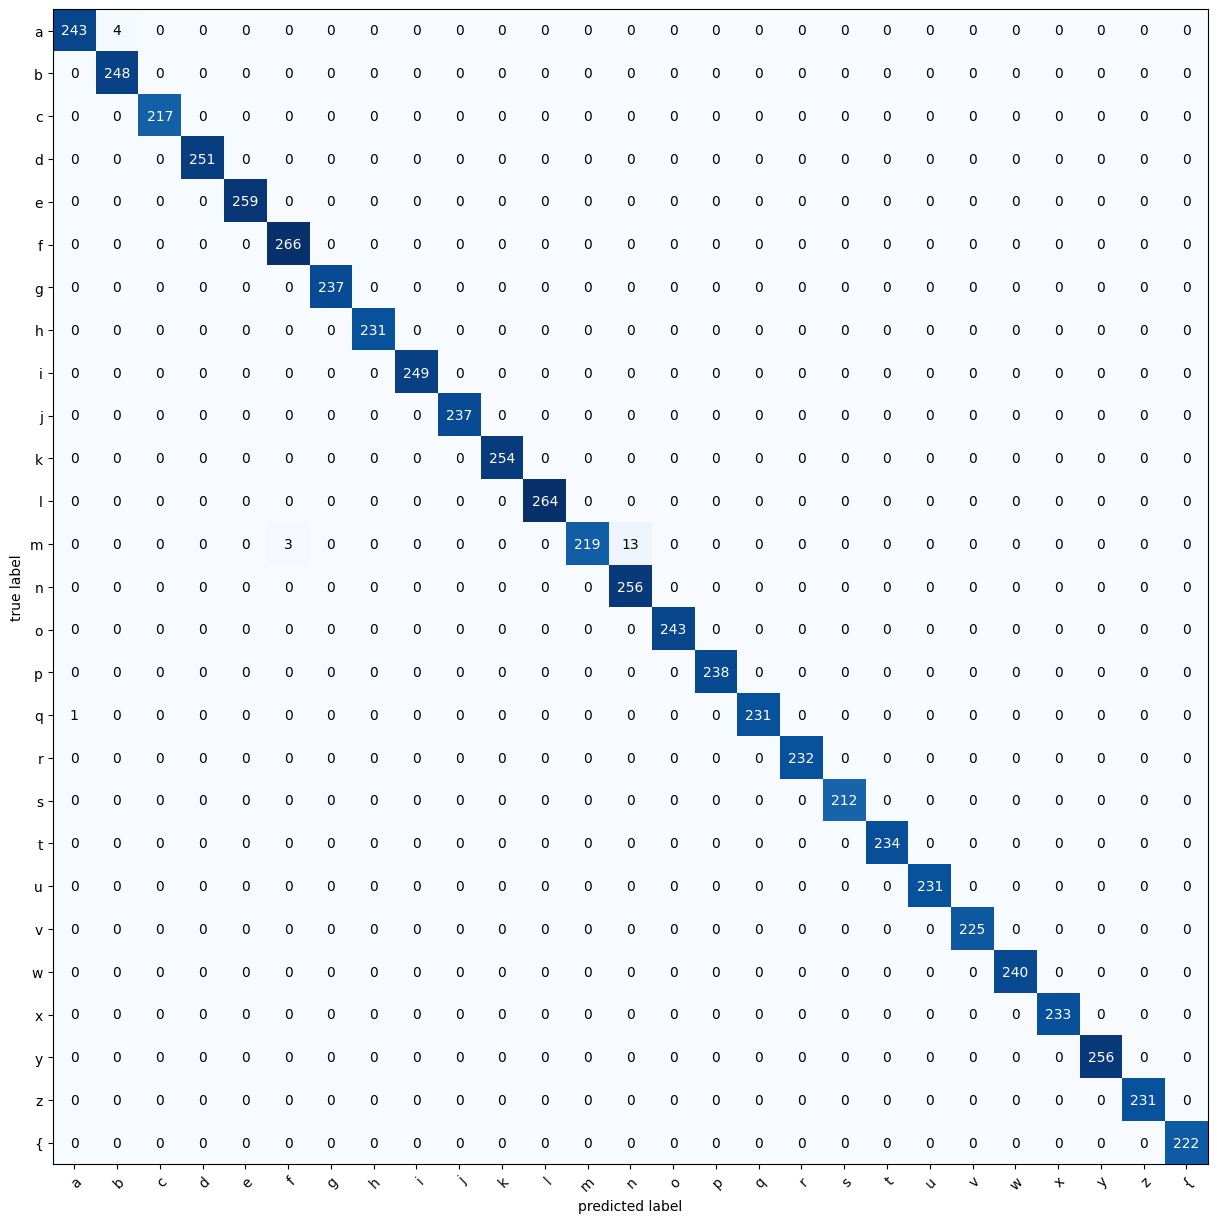

In [44]:
all_preds = []
all_labels = []

model_0.eval()
with torch.inference_mode():
    for X, Y in test_dataloader:
        X, Y = X.to(device), Y.to(device)
        preds = model_0(X).argmax(dim=1)
        all_preds.append(preds.cpu())
        all_labels.append(Y.cpu())

all_preds = torch.cat(all_preds)
all_labels = torch.cat(all_labels)

mat = ConfusionMatrix(num_classes=len(class_names), task="multiclass")
mat_tensor = mat(preds=all_preds, target=all_labels)

fig, ax = plot_confusion_matrix(
    conf_mat=mat_tensor.numpy(),
    class_names=class_names,
    figsize=(15, 15)
)